In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(0)
plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2,
                     'axes.grid': True, 'grid.alpha': 0.3})

COLORS = {'DRS': '#1f77b4', 'ADRS': '#ff7f0e',
          'ADRS-M': '#2ca02c', 'ADRS-NM': '#d62728'}
STYLES = {'DRS': '-', 'ADRS': '--', 'ADRS-M': '-.', 'ADRS-NM': ':'}


## Algorithms
DRS:$$x_k = \mathrm{prox}_{\alpha g_1}(z_k),\quad u_k = \mathrm{prox}_{\alpha g_2}(2x_k - z_k),\quad z_{k+1} = z_k + u_k - x_k$$


In [2]:
def make_algorithms(prox1, prox2, objective, ALPHA):
    """Return all four algorithms bound to a specific problem's prox operators."""

    # ------------------------------------------------------------------
    # DRS
    # ------------------------------------------------------------------
    def run_drs(z0, niters):
        z = z0.copy(); objs, resids = [], []
        for _ in range(niters):
            x = prox1(z, ALPHA)
            u = prox2(2*x - z, ALPHA)
            r = np.linalg.norm(u - x)
            z = z + u - x
            objs.append(objective(u)); resids.append(r)
        return np.array(objs), np.array(resids)

    # ------------------------------------------------------------------
    # ADRS: inertial DRS + residual restart
    # ------------------------------------------------------------------
    def run_adrs(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t, r_prev = 1.0, np.inf
        objs, resids = [], []
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)
            x = prox1(y, ALPHA); u = prox2(2*x - y, ALPHA)
            r = np.linalg.norm(u - x)
            if r > r_prev:                        # restart
                t_new = 1.0
                x_s = prox1(z, ALPHA); u_s = prox2(2*x_s - z, ALPHA)
                r   = np.linalg.norm(u_s - x_s)
                z_prev = z.copy(); z = z + u_s - x_s; u = u_s
            else:
                z_prev = z.copy(); z = y + u - x
            t, r_prev = t_new, r
            objs.append(objective(u)); resids.append(r)
        return np.array(objs), np.array(resids)

    # ------------------------------------------------------------------
    # ADRS-M: monitor variant — always compute both candidates
    # ------------------------------------------------------------------
    def run_adrs_m(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t = 1.0; objs, resids = [], []; n_in = 0
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)
            xI = prox1(y, ALPHA); uI = prox2(2*xI - y, ALPHA); rI = np.linalg.norm(uI - xI)
            xS = prox1(z, ALPHA); uS = prox2(2*xS - z, ALPHA); rS = np.linalg.norm(uS - xS)
            if rI <= rS:
                z_prev, z, u, r = z.copy(), y + uI - xI, uI, rI; n_in += 1
            else:
                z_prev, z, u, r = z.copy(), z + uS - xS, uS, rS; t_new = 1.0
            t = t_new
            objs.append(objective(u)); resids.append(r)
        print(f"  ADRS-M:    inertial {n_in}/{niters} ({100*n_in/niters:.0f}%)")
        return np.array(objs), np.array(resids)

    # ------------------------------------------------------------------
    # ADRS-NM: nonmonotone monitor — safe step only when needed
    # ------------------------------------------------------------------
    def run_adrs_m_nm(z0, niters, eta=0.1, delta=1e-4):
        z, z_prev = z0.copy(), z0.copy()
        t = 1.0
        xi = prox1(z, ALPHA); ui = prox2(2*xi - z, ALPHA)
        r0 = np.linalg.norm(ui - xi)
        c, q = r0, 1.0                    # c is weighted avg of past residuals, q is weight sum
        objs, resids = [], []; n_in = 0

        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)

            xI = prox1(y, ALPHA); uI = prox2(2*xI - y, ALPHA)
            rI = np.linalg.norm(uI - xI)

            if rI <= c - delta * rI**2:           # sufficient decrease vs nonmonotone ref
                z_prev, z, u, r = z.copy(), y + uI - xI, uI, rI; n_in += 1
                t = t_new
            else:
                xS = prox1(z, ALPHA); uS = prox2(2*xS - z, ALPHA)
                rS = np.linalg.norm(uS - xS)
                z_prev, z, u, r = z.copy(), z + uS - xS, uS, rS
                t = 1.0                           # reset momentum

            # update nonmonotone reference (Li & Lin eq. for q and c)
            q_new = eta * q + 1
            c     = (eta * q * c + r) / q_new
            q     = q_new

            objs.append(objective(u)); resids.append(r)

        print(f"  ADRS-NM:    inertial {n_in}/{niters} ({100*n_in/niters:.0f}%)")
        return np.array(objs), np.array(resids)

    return {'DRS': run_drs, 'ADRS': run_adrs,
            'ADRS-M': run_adrs_m, 'ADRS-NM': run_adrs_m_nm}


In [3]:
def format_time_seconds(seconds):
    return f"{max(0.01, np.ceil(seconds * 100) / 100):.2f}"


def run_and_plot(algos, z0, niters, f_star, title, fname=None):
    """Run all algorithms and produce the standard two-panel plot."""
    from time import perf_counter

    results = {}
    timings = {}
    print(f"Running: {title}")
    for name, fn in algos.items():
        t0 = perf_counter()
        results[name] = fn(z0, niters)
        timings[name] = perf_counter() - t0
        print(f"  {name:<11} {timings[name]:.2f}s")

    iters = np.arange(1, niters + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Use a small floor so objective gaps can be shown on log-scale even with tiny numerical negatives.
    gap_floor = 1e-16
    for name, (objs, resids) in results.items():
        c, ls = COLORS[name], STYLES[name]
        label = f"{name} ({timings[name]:.2f}s)"
        obj_gap = np.maximum(objs - f_star, gap_floor)
        axes[0].loglog(iters, obj_gap, color=c, linestyle=ls, label=label)
        axes[1].semilogy(iters, resids, color=c, linestyle=ls, label=label)

    axes[0].axhline(gap_floor, color='black', lw=1, linestyle='--', label='Gap floor')
    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('$F(u_k) - F^\\star$')
    axes[0].set_title('Objective gap'); axes[0].legend(fontsize=10)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('$r_k = \\|u_k - x_k\\|$')
    axes[1].set_title('DRS residual'); axes[1].legend(fontsize=10)

    runtime_text = "   ".join(f"{name}: {timings[name]:.2f}s" for name in algos)
    fig.text(0.5, 0.01, f"Wall time per algorithm: {runtime_text}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

    # Final objective values
    print(f"\n{'Algorithm':<14} {'Final Objective':>16}")
    print("-" * 33)
    for name, (objs, _) in results.items():
        print(f"{name:<14} {objs[-1]:>16.6f}")

    # Summary table
    tols = [1.0, 0.1, 0.01, 1e-3, 1e-4]
    print(f"\n{'Algorithm':<14}", end="")
    for t in tols:
        print(f"  gap<{t:.0e}", end="")
    print()
    print("-" * 65)
    for name, (objs, _) in results.items():
        gaps = objs - f_star
        print(f"{name:<14}", end="")
        for t in tols:
            h = np.where(gaps < t)[0]
            print(f"  {str(h[0]+1) if len(h) else 'N/A':>8}", end="")
        print()
    print()
    return results


---
## Problem 1: Basis Pursuit

$$\min_{x \in \mathbb{R}^n} \|x\|_1 \quad\text{s.t.}\quad Ax = b$$

In [4]:
np.random.seed(0)
n, m = 1000, 400          #m = 0.4*n
s = 40

A = np.random.randn(m, n) / np.sqrt(m)
x_true = np.zeros(n)
x_true[np.random.choice(n, s, replace=False)] = np.random.randn(s)
b = A @ x_true
AAT_inv = np.linalg.inv(A @ A.T)

prox1_bp = lambda z, a: np.sign(z) * np.maximum(np.abs(z) - a, 0)
prox2_bp = lambda z, a: z - A.T @ (AAT_inv @ (A @ z - b))
obj_bp   = lambda u: np.sum(np.abs(u))

F_STAR_BP = np.sum(np.abs(x_true))
z0_bp     = np.random.randn(n)
ALPHA_BP  = 1.0
NITERS_BP = 300

print(f"n={n}, m={m}, s={s},  F* = ||x_true||_1 = {F_STAR_BP:.6f}")

algos_bp = make_algorithms(prox1_bp, prox2_bp, obj_bp, ALPHA_BP)


n=1000, m=400, s=40,  F* = ||x_true||_1 = 36.700654


Running: Problem 1: Basis Pursuit  —  min ||x||₁  s.t.  Ax = b
  DRS         0.04s
  ADRS        0.04s
  ADRS-M:    inertial 154/300 (51%)
  ADRS-M      0.07s
  ADRS-NM:    inertial 225/300 (75%)
  ADRS-NM     0.04s


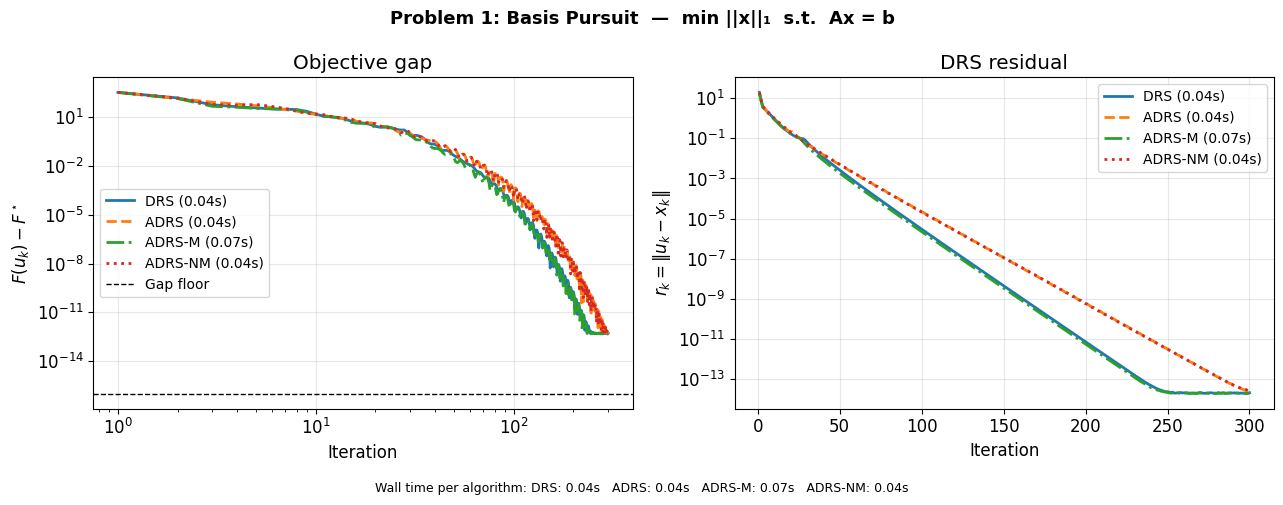


Algorithm       Final Objective
---------------------------------
DRS                   36.700654
ADRS                  36.700654
ADRS-M                36.700654
ADRS-NM               36.700654

Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                   30        44        62        77        95
ADRS                  31        48        64        79       100
ADRS-M                27        43        57        70        89
ADRS-NM               31        48        64        89       105



In [16]:
res_bp = run_and_plot(
    algos_bp, z0_bp, NITERS_BP, F_STAR_BP,
    title="Problem 1: Basis Pursuit  —  min ||x||₁  s.t.  Ax = b",
    fname="p1_basis_pursuit.png"
)


---
## Problem 2: Nuclear Norm Distance + Nonnegativity Constraint

$$\min_{X \in \mathbb{R}^{m\times n}} \|X - M\|_* \quad\text{s.t.}\quad X \geq 0$$


In [6]:
np.random.seed(2)
rows, cols, rank = 20, 20, 3

L  = np.random.randn(rows, rank)
R  = np.random.randn(cols, rank)
M  = L @ R.T      # low-rank matrix with mixed signs (nontrivial nonneg projection)

def prox1_nuc(Z, alpha):
    """prox_{alpha * ||. - M||_*}: shifted singular value soft thresholding."""
    D = Z - M
    U, s, Vt = np.linalg.svd(D, full_matrices=False)
    return M + (U * np.maximum(s - alpha, 0)) @ Vt

prox2_nuc = lambda Z, a: np.maximum(Z, 0)           # projection onto nonneg orthant
obj_nuc   = lambda U: float(np.sum(np.linalg.svd(U - M, compute_uv=False)))

# F* via CVX
import cvxpy as cp
import numpy as np
X = cp.Variable((rows, cols))
prob = cp.Problem(
    cp.Minimize(cp.normNuc(X - M)),
    [X >= 0]
)
prob.solve(solver=cp.SCS, eps=1e-12, max_iters=200000)
F_STAR_NUC = prob.value
print(f"F* (CVXPY) = {F_STAR_NUC:.12f}")

z0_nuc    = np.random.randn(rows, cols)
ALPHA_NUC = 1.0
NITERS_NUC = 100000

print(f"{rows}x{cols} matrix, rank={rank}")
print(f"F* = {F_STAR_NUC:.6f}")

algos_nuc = make_algorithms(prox1_nuc, prox2_nuc, obj_nuc, ALPHA_NUC)


F* (CVXPY) = 53.940277105406
20x20 matrix, rank=3
F* = 53.940277


/tmp/ipykernel_800847/345008230.py:25: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, eps=1e-12, max_iters=200000)


Running: Problem 2: Nuclear Norm  —  min ||X-M||_*  s.t.  X ≥ 0
  DRS         5.40s
  ADRS        6.81s
  ADRS-M:    inertial 75040/100000 (75%)
  ADRS-M      9.40s
  ADRS-NM:    inertial 68175/100000 (68%)
  ADRS-NM     6.80s


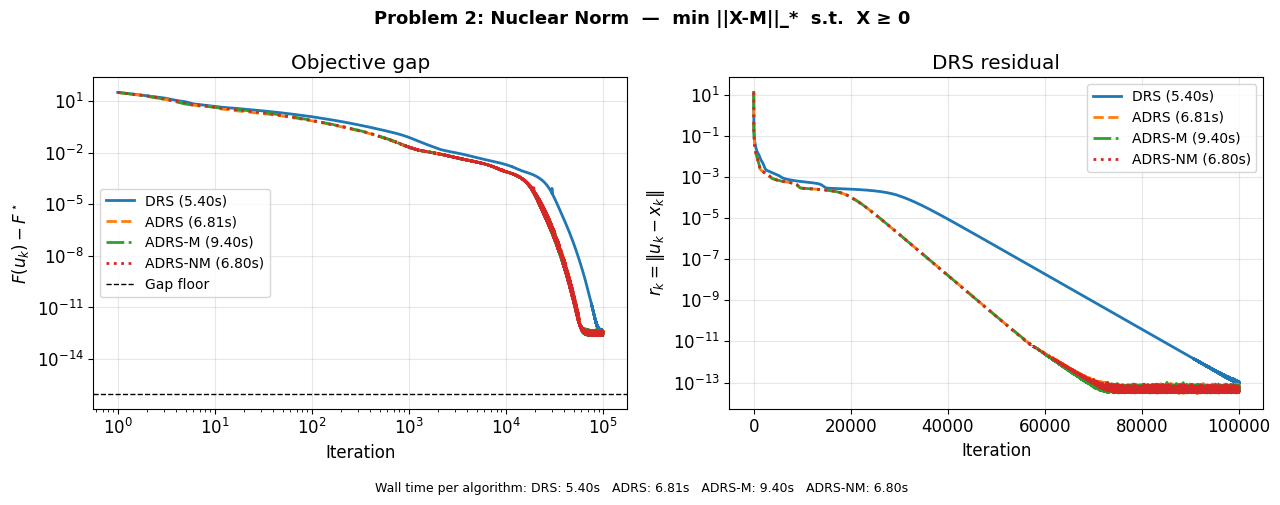


Algorithm       Final Objective
---------------------------------
DRS                   53.940277
ADRS                  53.940277
ADRS-M                53.940277
ADRS-NM               53.940277

Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                  124       870      2983     13654     27309
ADRS                  68       452      1715      8735     17737
ADRS-M                76       466      1732      8745     17748
ADRS-NM               72       463      1709      8730     17732



In [17]:
res_nuc = run_and_plot(
    algos_nuc, z0_nuc, NITERS_NUC, F_STAR_NUC,
    title="Problem 2: Nuclear Norm  —  min ||X-M||_*  s.t.  X ≥ 0",
    fname="p2_nuclear_norm.png"
)


---
## Problem 3: Constrained Elastic Net

$$\min_{x \in \mathbb{R}^n} \|x\|_1 + \frac{\mu}{2}\|x\|^2 \quad\text{s.t.}\quad Ax = b$$


In [9]:
np.random.seed(0)
n, m, s = 1000, 400, 40
mu = 1    

A2 = np.random.randn(m, n) / np.sqrt(m)
x_true2 = np.zeros(n)
x_true2[np.random.choice(n, s, replace=False)] = np.random.randn(s)
b2 = A2 @ x_true2
AAT_inv2 = np.linalg.inv(A2 @ A2.T)

def prox1_en(z, alpha):
    """prox_{alpha*(||.||_1 + mu/2*||.||^2)}: scaled soft thresholding."""
    return np.sign(z) * np.maximum(np.abs(z) - alpha, 0) / (1 + alpha * mu)

prox2_en = lambda z, a: z - A2.T @ (AAT_inv2 @ (A2 @ z - b2))
obj_en   = lambda u: np.sum(np.abs(u)) + (mu/2) * np.sum(u**2)

# F* via CVX
x = cp.Variable(n)
prob = cp.Problem(
    cp.Minimize(cp.norm1(x) + (mu / 2) * cp.sum_squares(x)),
    [A @ x == b]
)
prob.solve(solver=cp.CLARABEL)
F_STAR_EN = prob.value

z0_en    = np.random.randn(n)
ALPHA_EN = 1.0
NITERS_EN = 1000

print(f"n={n}, m={m}, s={s}, mu={mu}")
print(f"F* = {F_STAR_EN:.6f}")

algos_en = make_algorithms(prox1_en, prox2_en, obj_en, ALPHA_EN)


n=1000, m=400, s=40, mu=1
F* = 59.041600


Running: Problem 3: Constrained Elastic Net  —  min ||x||₁ + (μ/2)||x||²  s.t.  Ax = b
  DRS         0.11s
  ADRS        0.16s
  ADRS-M:    inertial 633/1000 (63%)
  ADRS-M      0.20s
  ADRS-NM:    inertial 461/1000 (46%)
  ADRS-NM     0.16s


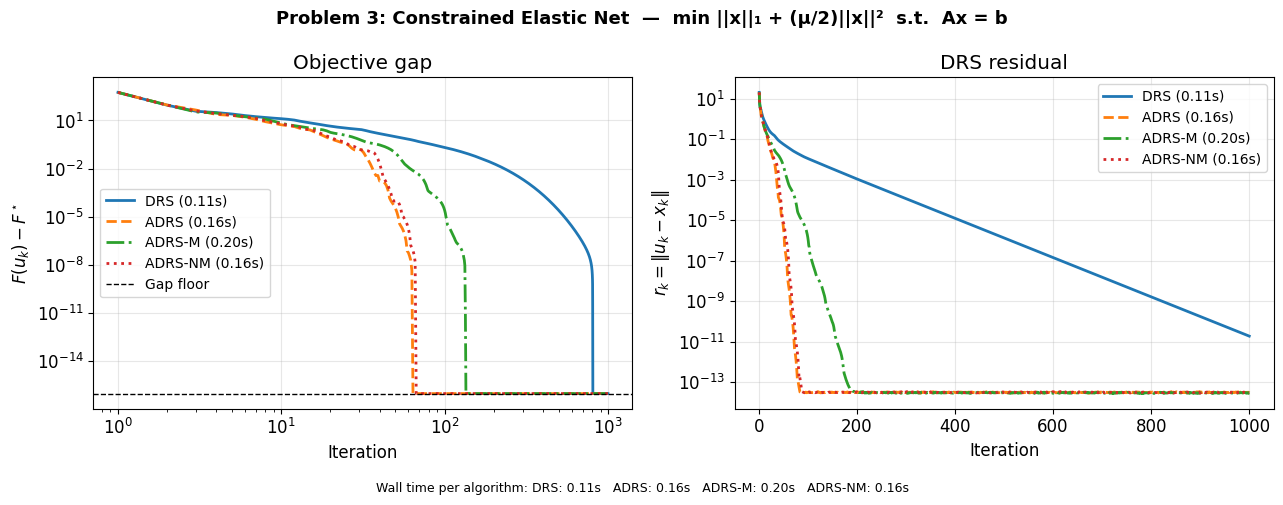


Algorithm       Final Objective
---------------------------------
DRS                   59.041600
ADRS                  59.041600
ADRS-M                59.041600
ADRS-NM               59.041600

Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                   50       132       233       336       439
ADRS                  19        32        37        44        47
ADRS-M                27        50        62        77        94
ADRS-NM               20        37        41        45        49



In [18]:
res_en = run_and_plot(
    algos_en, z0_en, NITERS_EN, F_STAR_EN,
    title="Problem 3: Constrained Elastic Net  —  min ||x||₁ + (μ/2)||x||²  s.t.  Ax = b",
    fname="p3_elastic_net.png"
)


---
## Lasso

$$\min_x \frac{1}{2}\|Ax-b\|^2 + \lambda\|x\|_1$$


F* (CVXPY)  = 7.39792989
n=1000, m=500, s=100, lam=0.1
Running: Final experiment: Lasso  —  min (1/2)||Ax-b||² + λ||x||₁
  DRS         2.72s
  ADRS        2.48s
  ADRS-M:    inertial 137/200 (68%)
  ADRS-M      4.59s
  ADRS-NM:    inertial 184/200 (92%)
  ADRS-NM     2.48s


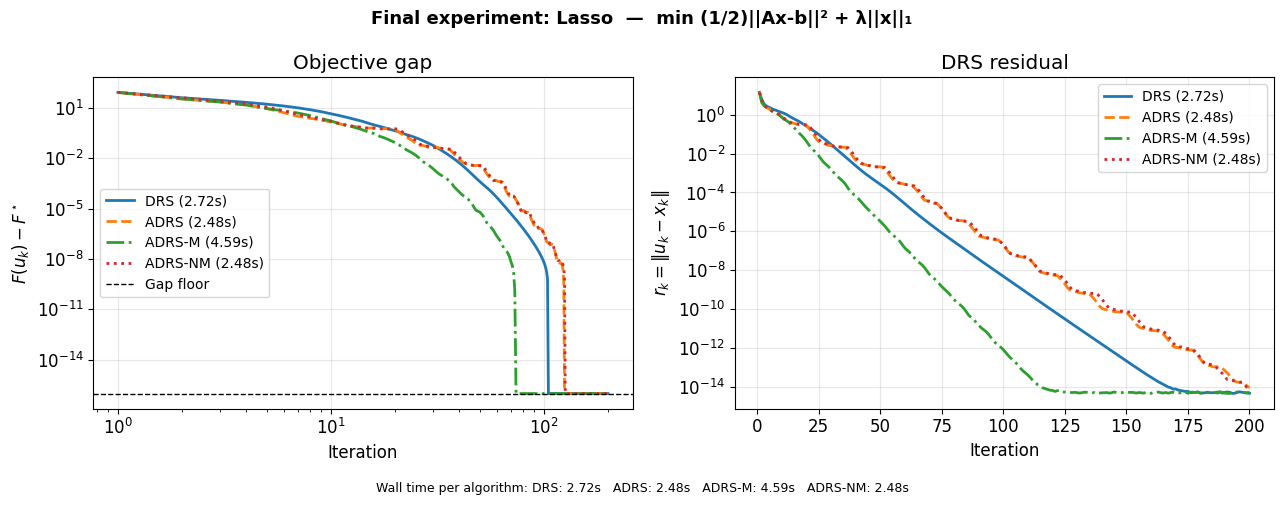


Algorithm       Final Objective
---------------------------------
DRS                    7.397930
ADRS                   7.397930
ADRS-M                 7.397930
ADRS-NM                7.397930

Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                   16        28        38        47        57
ADRS                  12        25        40        55        67
ADRS-M                12        20        26        33        40
ADRS-NM               12        26        41        56        68



In [19]:
import cvxpy as cp

np.random.seed(1)
n, m, s = 1000, 500, 100
lam = 0.1
A_lasso = np.random.randn(m, n) / np.sqrt(m)
x_true_lasso = np.zeros(n)
x_true_lasso[np.random.choice(n, s, replace=False)] = np.random.randn(s)
b_lasso = A_lasso @ x_true_lasso + 0.02 * np.random.randn(m)
ALPHA_LASSO = 1.0
Q_lasso = np.eye(n) + ALPHA_LASSO * (A_lasso.T @ A_lasso)

prox1_lasso = lambda z, a: np.sign(z) * np.maximum(np.abs(z) - a * lam, 0)

def prox2_lasso(z, alpha):
    rhs = z + ALPHA_LASSO * (A_lasso.T @ b_lasso)
    return np.linalg.solve(Q_lasso, rhs)

obj_lasso = lambda u: 0.5 * np.sum((A_lasso @ u - b_lasso)**2) + lam * np.sum(np.abs(u))

# F* via CVXPY 
x_var = cp.Variable(n)
prob = cp.Problem(
    cp.Minimize(0.5 * cp.sum_squares(A_lasso @ x_var - b_lasso) + lam * cp.norm1(x_var))
)
prob.solve(solver=cp.CLARABEL)
F_STAR_LASSO = prob.value
print(f"F* (CVXPY)  = {F_STAR_LASSO:.8f}")

z0_lasso = np.random.randn(n)
NITERS_LASSO = 200
print(f"n={n}, m={m}, s={s}, lam={lam}")
algos_lasso = make_algorithms(prox1_lasso, prox2_lasso, obj_lasso, ALPHA_LASSO)
res_lasso = run_and_plot(
    algos_lasso, z0_lasso, NITERS_LASSO, F_STAR_LASSO,
    title="Final experiment: Lasso  —  min (1/2)||Ax-b||² + λ||x||₁",
    fname="p4_lasso.png"
)

---
## Cross-problem comparison

Speedup of ADRS-M over DRS: how many fewer iterations to reach each tolerance?


In [25]:
tols = [1.0, 0.1, 0.01, 1e-3, 1e-4]
target_gap = 1e-12
problem_results = [
    ("Basis Pursuit", res_bp, F_STAR_BP, NITERS_BP),
    ("Nuclear Norm", res_nuc, F_STAR_NUC, NITERS_NUC),
    ("Elastic Net", res_en, F_STAR_EN, NITERS_EN),
    ("Lasso", res_lasso, F_STAR_LASSO, NITERS_LASSO),
]

problem_run_times = {
        "Basis Pursuit": {"DRS": 0.04, "ADRS": 0.04, "ADRS-M": 0.07, "ADRS-NM": 0.04},
        "Nuclear Norm": {"DRS": 5.40, "ADRS": 6.81, "ADRS-M": 9.40, "ADRS-NM": 6.80},
        "Elastic Net": {"DRS": 0.11, "ADRS": 0.16, "ADRS-M": 0.20, "ADRS-NM": 0.16},
        "Lasso": {"DRS": 2.72, "ADRS": 2.48, "ADRS-M": 4.59, "ADRS-NM": 2.48},
}

problem_times = {}
for pname, res, fstar, ni in problem_results:
    problem_times[pname] = {}
    for method in ['DRS', 'ADRS', 'ADRS-M', 'ADRS-NM']:
        gaps = res[method][0] - fstar
        h = np.where(gaps < target_gap)[0]
        if len(h):
            problem_times[pname][method] = problem_run_times[pname][method] * (h[0] + 1) / ni
        else:
            problem_times[pname][method] = np.nan

print(f"{'Problem':<18}  {'Method':<10}  {'r<1e+00':>8}  {'r<1e-01':>8}  {'r<1e-02':>8}  {'r<1e-03':>8}  {'r<1e-04':>8}  {'Time to convergence':>22}")
print("-" * 120)
for pname, res, fstar, ni in problem_results:
    first_method = True
    timings_for_problem = problem_times[pname]
    for method in ['DRS', 'ADRS', 'ADRS-M', 'ADRS-NM']:
        gaps = res[method][0] - fstar
        hits = []
        for t in tols:
            h = np.where(gaps < t)[0]
            hits.append(str(h[0] + 1) if len(h) else 'N/A')
        problem_label = pname if first_method else ""
        time_value = timings_for_problem[method]
        time_str = f"{time_value:.2f}" if np.isfinite(time_value) else 'N/A'
        print(f"{problem_label:<18}  {method:<10}  {hits[0]:>8}  {hits[1]:>8}  {hits[2]:>8}  {hits[3]:>8}  {hits[4]:>8}  {time_str:>22}")
        first_method = False
    print()


Problem             Method       r<1e+00   r<1e-01   r<1e-02   r<1e-03   r<1e-04     Time to convergence
------------------------------------------------------------------------------------------------------------------------
Basis Pursuit       DRS               30        44        62        77        95                    0.03
                    ADRS              31        48        64        79       100                    0.04
                    ADRS-M            27        43        57        70        89                    0.05
                    ADRS-NM           31        48        64        89       105                    0.04

Nuclear Norm        DRS              124       870      2983     13654     27309                    4.63
                    ADRS              68       452      1715      8735     17737                    3.91
                    ADRS-M            76       466      1732      8745     17748                    5.40
                    ADRS-NM           

## Problem-wise plots

The next two figures compare all four problems side by side: first the objective curves, then the DRS residual curves.


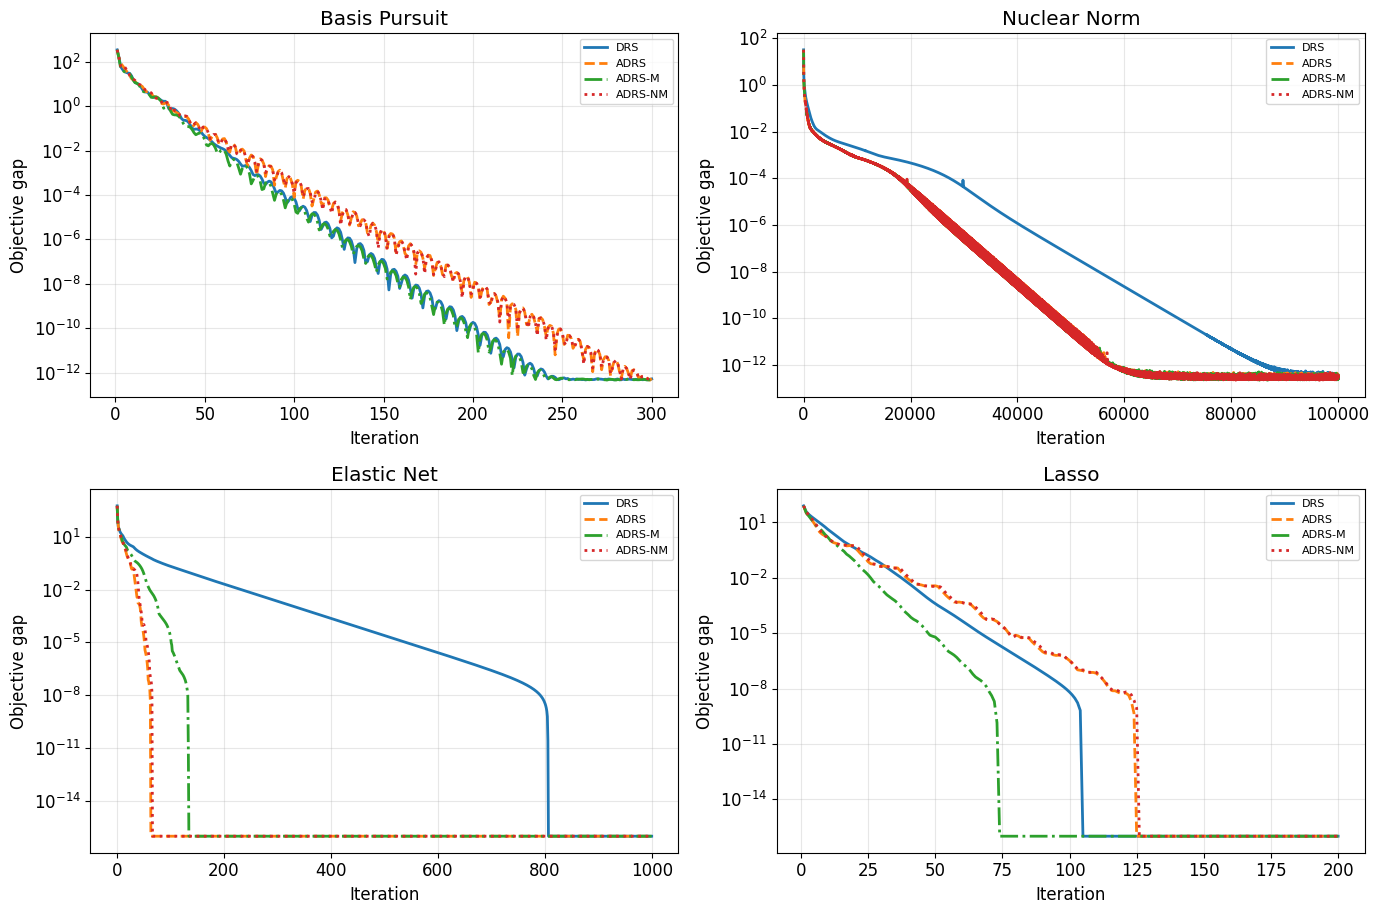

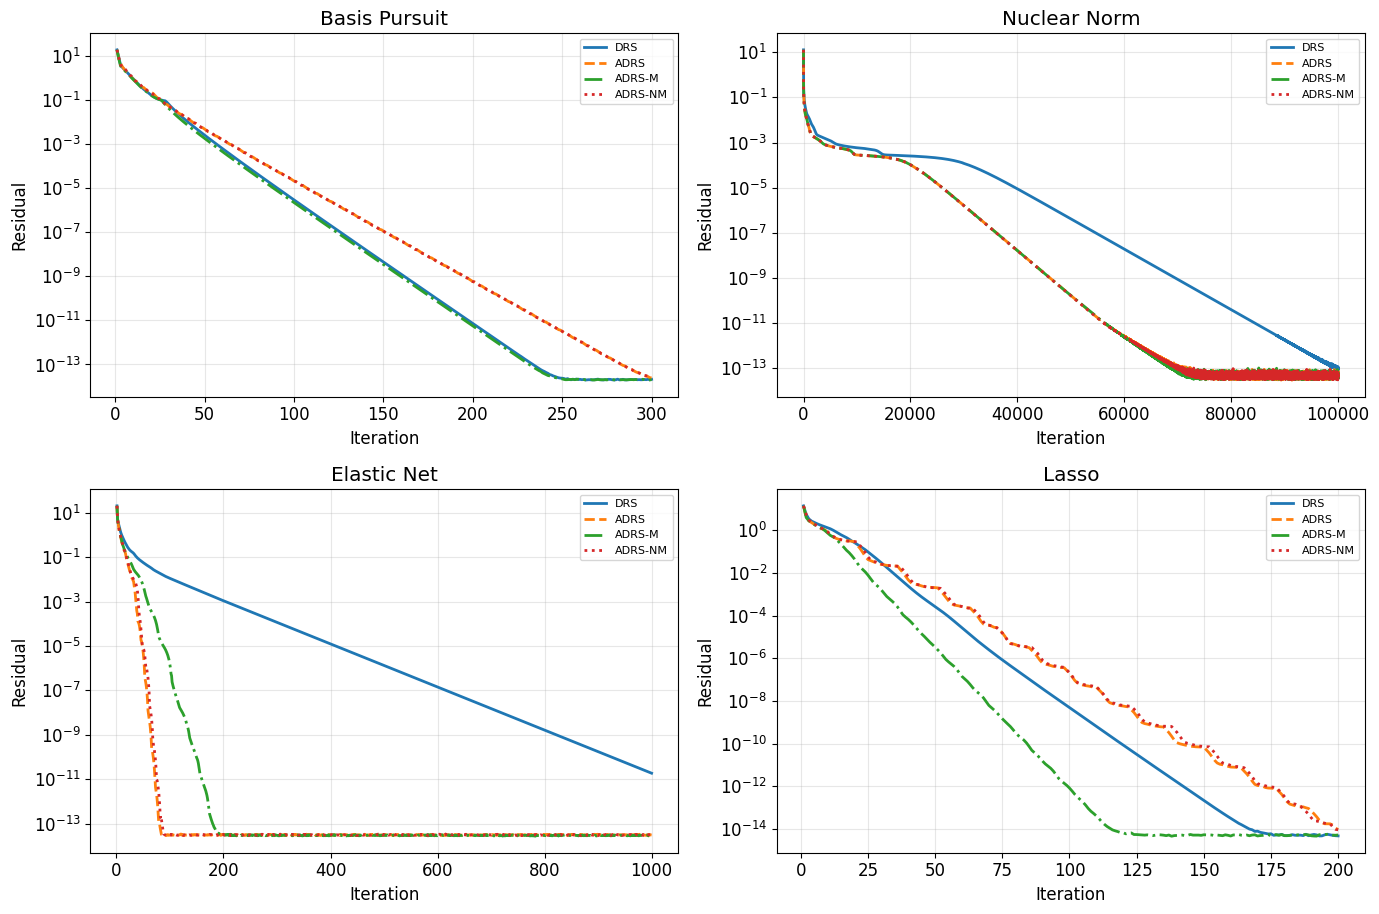

In [37]:
problem_panels = [
    ("Basis Pursuit", res_bp, F_STAR_BP, NITERS_BP),
    ("Nuclear Norm", res_nuc, F_STAR_NUC, NITERS_NUC),
    ("Elastic Net", res_en, F_STAR_EN, NITERS_EN),
    ("Lasso", res_lasso, F_STAR_LASSO, NITERS_LASSO),
]

# 4-panel objective-gap comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

gap_floor = 1e-16
for ax, (title, res, fstar, ni) in zip(axes, problem_panels):
    iters = np.arange(1, ni + 1)
    for name, result in res.items():
        objs, resids = result[:2]
        obj_gap = np.maximum(objs - fstar, gap_floor)
        ax.semilogy(iters, obj_gap, color=COLORS[name], linestyle=STYLES[name], label=name)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Objective gap')
    ax.legend(fontsize=8)

plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.savefig('objectives.png', dpi=130, bbox_inches='tight')
plt.show()

# 4-panel residual comparison with all algorithms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (title, res, fstar, ni) in zip(axes, problem_panels):
    iters = np.arange(1, ni + 1)
    for name, result in res.items():
        objs, resids = result[:2]
        ax.semilogy(iters, resids, color=COLORS[name], linestyle=STYLES[name], label=name)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual')
    ax.legend(fontsize=8)

plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.savefig('residuals.png', dpi=130, bbox_inches='tight')
plt.show()
